In [1]:
import pandas as pd
import numpy as np

# Load the Telco Customer Churn dataset directly from GitHub
url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Display dimensions and summary information
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()

Dataset Dimensions: 7043 rows, 21 columns

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessB

In [2]:
# 1. Convert TotalCharges to numeric values
# errors='coerce' turns invalid strings like ' ' into NaN (missing value)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check how many missing values were generated
missing_count = df['TotalCharges'].isnull().sum()
print(f"Hidden missing values found in TotalCharges: {missing_count}")

# 3. Inspect the rows with missing TotalCharges
print("\nRows where TotalCharges is missing:")
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

Hidden missing values found in TotalCharges: 11

Rows where TotalCharges is missing:


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [3]:
# 1. Fill missing TotalCharges with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. Drop customerID column
df = df.drop(columns=['customerID'])

# 3. Verify clean dataset info
print(f"Remaining columns: {df.shape[1]}")
print(f"Missing values in TotalCharges remaining: {df['TotalCharges'].isnull().sum()}")

Remaining columns: 20
Missing values in TotalCharges remaining: 0


Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


C:\Users\Likitha\AppData\Local\Temp\ipykernel_17008\187596062.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


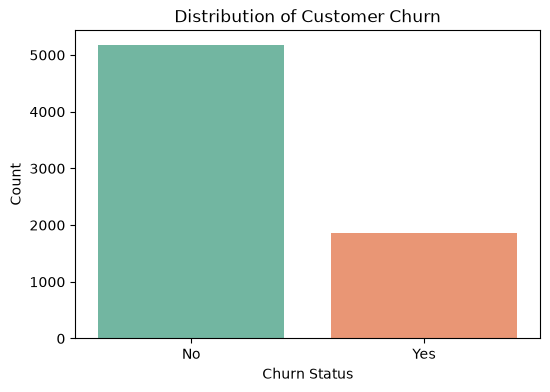

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate counts and percentages
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:")
print(churn_counts)
print("\nChurn Percentages:")
print(churn_percentages.round(2))

# Visualize target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.show()

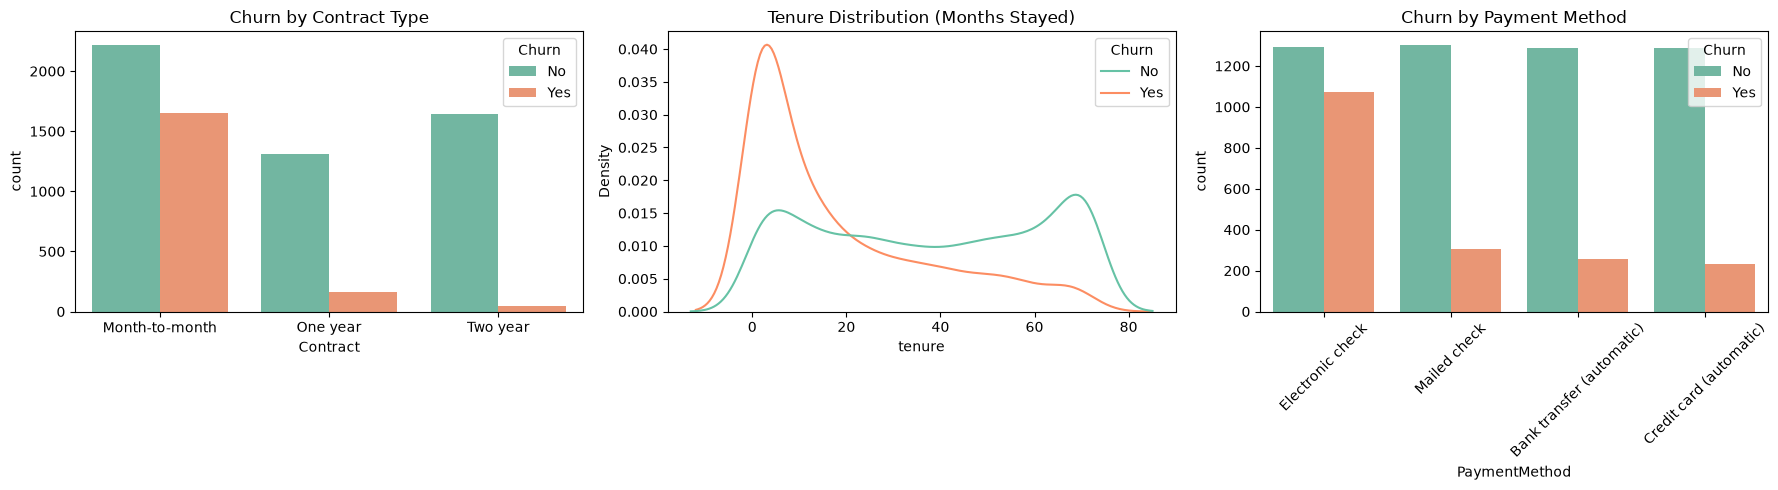

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Contract Type')

# 2. Tenure Distribution by Churn Status
sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, ax=axes[1], palette='Set2')
axes[1].set_title('Tenure Distribution (Months Stayed)')

# 3. Churn by Payment Method
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[2], palette='Set2')
axes[2].set_title('Churn by Payment Method')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [6]:
# Create a copy for preprocessing
df_model = df.copy()

# 1. Convert target variable 'Churn' into binary integers (Yes -> 1, No -> 0)
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# 2. Convert categorical text features into numerical dummy columns (One-Hot Encoding)
df_encoded = pd.get_dummies(df_model, drop_first=True, dtype=int)

print(f"Original features count: {df.shape[1]}")
print(f"Encoded features count: {df_encoded.shape[1]}")
df_encoded.head()

Original features count: 20
Encoded features count: 31


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [7]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 2. Perform stratified train-test split
# stratify=y ensures both train and test sets have the exact same 73/27 churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training feature set shape: {X_train.shape}")
print(f"Testing feature set shape: {X_test.shape}")
print(f"Training Churn distribution:\n{y_train.value_counts(normalize=True).round(4)}")

Training feature set shape: (5634, 30)
Testing feature set shape: (1409, 30)
Training Churn distribution:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Initialize Logistic Regression with class weight adjustment
# class_weight='balanced' gives extra weight to the minority class (Churn=1)
baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# 2. Train the model on the training set
baseline_model.fit(X_train, y_train)

# 3. Predict on the unseen testing set
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

# 4. Print performance report
print("=== Baseline Logistic Regression Performance ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

=== Baseline Logistic Regression Performance ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8423


C:\Users\Likitha\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from xgboost import XGBClassifier

# 1. Calculate scale_pos_weight for class imbalance handling
# ratio = count(Negative) / count(Positive)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Initialize and train XGBoost
xgb_model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 3. Predict on test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 4. Output performance metrics
print("=== XGBoost Performance ===")
print(classification_report(y_test, y_pred_xgb))
print(f"XGBoost ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

=== XGBoost Performance ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

XGBoost ROC-AUC Score: 0.8440


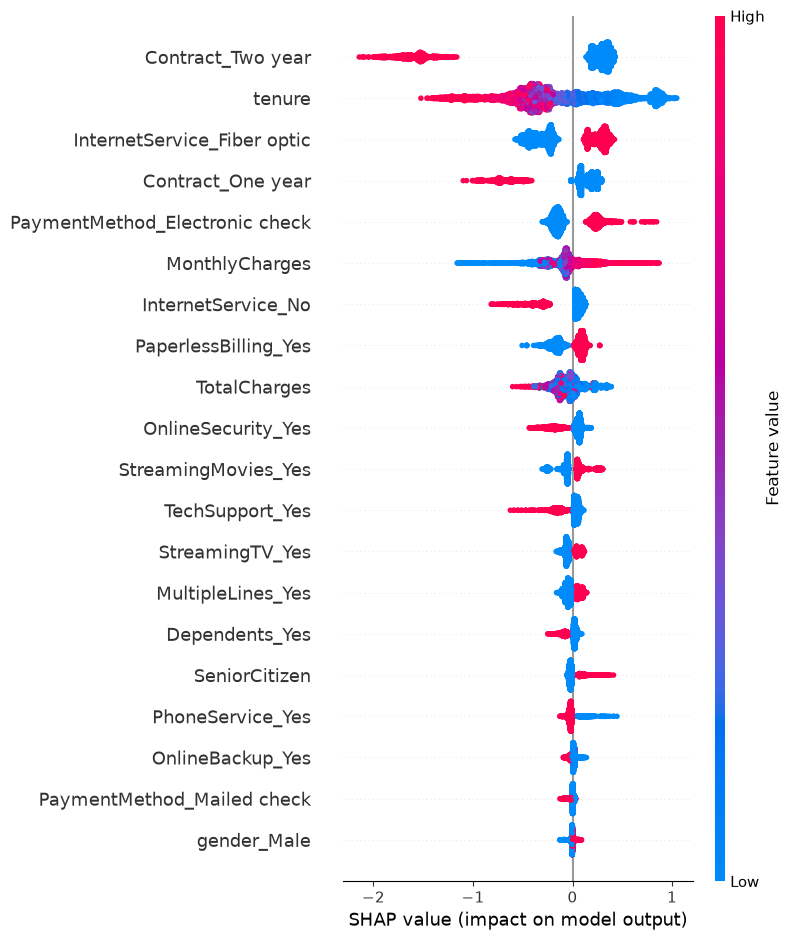

In [10]:
import shap

# 1. Initialize TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_train)

# 2. Summary plot showing global feature importance
shap.summary_plot(shap_values, X_train)

In [11]:
import joblib

# Save the trained XGBoost model and training column names
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

print("Model and columns successfully saved!")

Model and columns successfully saved!
